# Import Libraries & Load Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("data/WHR2024.csv")

# Preview Dataset
display(df.head())

# Dataset Size
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


Rows: 143
Columns: 11


# Dataset Overview

In [6]:
# Column Names
print(df.columns.tolist())

# Dataset Information
df.info()

# Statistical Summary
display(df.describe())

['Country name', 'Ladder score', 'upperwhisker', 'lowerwhisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
<class 'pandas.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                143 non-null    str    
 1   Ladder score                                143 non-null    float64
 2   upperwhisker                                143 non-null    float64
 3   lowerwhisker                                143 non-null    float64
 4   Explained by: Log GDP per capita            140 non-null    float64
 5   Explained by: Social support                140 non-null    float64
 6   Exp

,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,143.000000,143.000000,143.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,5.527580,5.641175,5.413972,1.378807,1.134329,0.520886,0.620621,0.146271,0.154121,1.575914
std,1.170717,1.155008,1.187133,0.425098,0.333317,0.164923,0.162492,0.073441,0.126238,0.537459
min,1.721000,1.775000,1.667000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.073000
25%,4.726000,4.845500,4.606000,1.077750,0.921750,0.398000,0.527500,0.091000,0.068750,1.308250
50%,5.785000,5.895000,5.674000,1.431500,1.237500,0.549500,0.641000,0.136500,0.120500,1.644500
75%,6.416000,6.507500,6.319000,1.741500,1.383250,0.648500,0.736000,0.192500,0.193750,1.881750
max,7.741000,7.815000,7.667000,2.141000,1.617000,0.857000,0.863000,0.401000,0.575000,2.998000


# Data Cleaning

In [7]:
# Missing Values
display(df.isnull().sum())

# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove Duplicates
df = df.drop_duplicates()

print("Dataset Shape After Cleaning:", df.shape)

Country name                                  0
Ladder score                                  0
upperwhisker                                  0
lowerwhisker                                  0
Explained by: Log GDP per capita              3
Explained by: Social support                  3
Explained by: Healthy life expectancy         3
Explained by: Freedom to make life choices    3
Explained by: Generosity                      3
Explained by: Perceptions of corruption       3
Dystopia + residual                           3
dtype: int64

Duplicate Rows: 0
Dataset Shape After Cleaning: (143, 11)


# Happiness Score Analysis


count    143.000000
mean       5.527580
std        1.170717
min        1.721000
25%        4.726000
50%        5.785000
75%        6.416000
max        7.741000
Name: Ladder score, dtype: float64

,Country name,Ladder score
0,Finland,7.741
1,Denmark,7.583
2,Iceland,7.525
3,Sweden,7.344
4,Israel,7.341
5,Netherlands,7.319
6,Norway,7.302
7,Luxembourg,7.122
8,Switzerland,7.060
9,Australia,7.057


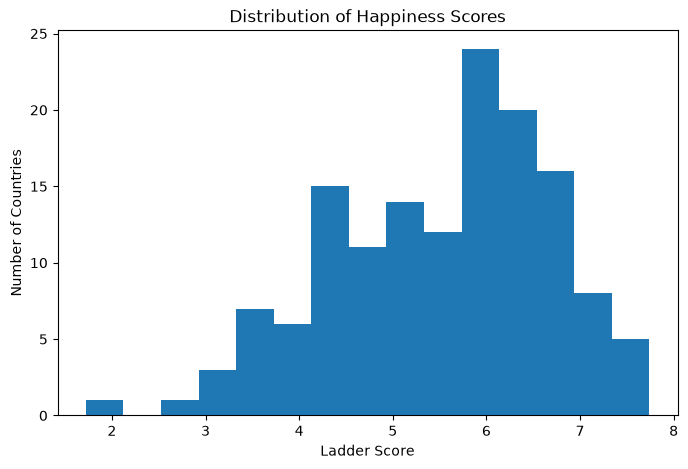

In [11]:
# Happiness Score Statistics
display(df["Ladder score"].describe())

# Top 10 Happiest Countries
top10 = df.nlargest(10, "Ladder score")[["Country name", "Ladder score"]]

display(top10)

plt.figure(figsize=(8,5))

plt.hist(df["Ladder score"], bins=15)

plt.title("Distribution of Happiness Scores")
plt.xlabel("Ladder Score")
plt.ylabel("Number of Countries")

plt.show()

# GDP Contribution Analysis

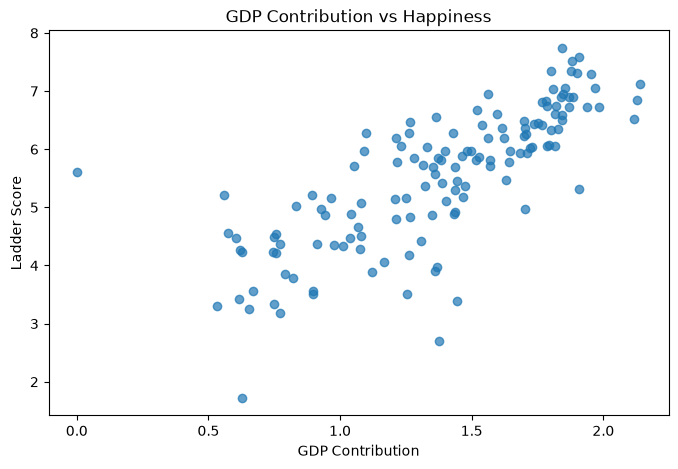

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Explained by: Log GDP per capita"],
    df["Ladder score"],
    alpha=0.7
)

plt.title("GDP Contribution vs Happiness")
plt.xlabel("GDP Contribution")
plt.ylabel("Ladder Score")

plt.show()

# Social Support Analysis

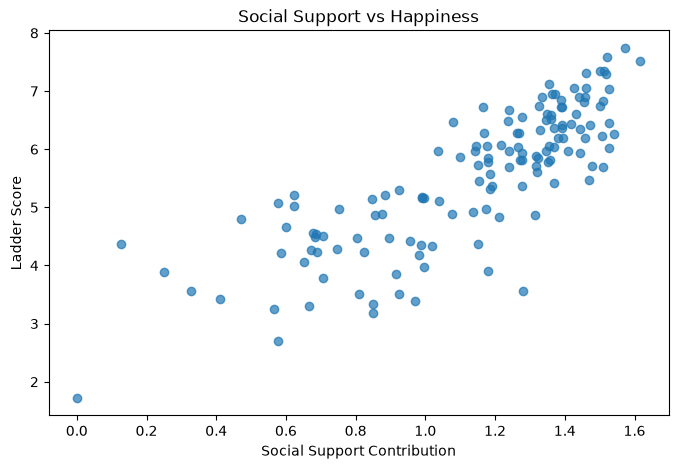

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Explained by: Social support"],
    df["Ladder score"],
    alpha=0.7
)

plt.title("Social Support vs Happiness")
plt.xlabel("Social Support Contribution")
plt.ylabel("Ladder Score")

plt.show()

# Healthy Life Expectancy Analysis

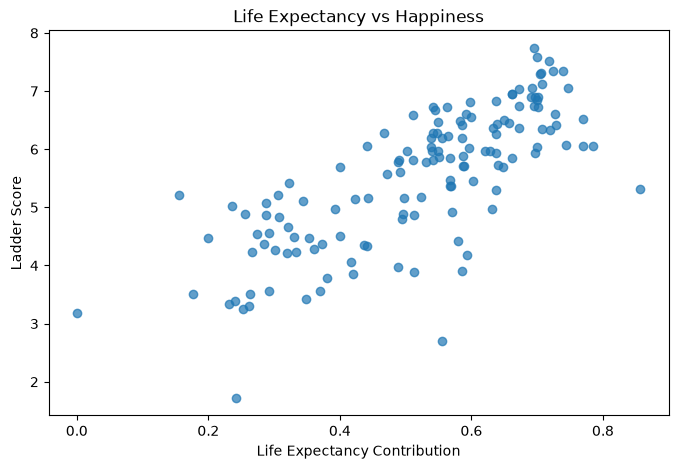

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Explained by: Healthy life expectancy"],
    df["Ladder score"],
    alpha=0.7
)

plt.title("Life Expectancy vs Happiness")
plt.xlabel("Life Expectancy Contribution")
plt.ylabel("Ladder Score")

plt.show()

# Correlation Analysis

In [15]:
corr = df.select_dtypes(include="number").corr()

display(corr)

display(corr["Ladder score"].sort_values(ascending=False))

,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
Ladder score,1.000000,0.999678,0.999697,0.768504,0.813542,0.759659,0.644451,0.130038,0.451829,0.533542
upperwhisker,0.999678,1.000000,0.998750,0.761804,0.811550,0.751042,0.646309,0.129602,0.448847,0.542267
lowerwhisker,0.999697,0.998750,1.000000,0.774531,0.814992,0.767506,0.642291,0.130446,0.454480,0.524816
Explained by: Log GDP per capita,0.768504,0.761804,0.774531,1.000000,0.726843,0.830256,0.414886,-0.059405,0.444227,-0.029118
Explained by: Social support,0.813542,0.811550,0.814992,0.726843,1.000000,0.706924,0.484641,0.079466,0.250870,0.159484
Explained by: Healthy life expectancy,0.759659,0.751042,0.767506,0.830256,0.706924,1.000000,0.401082,0.007148,0.399026,0.051538
Explained by: Freedom to make life choices,0.644451,0.646309,0.642291,0.414886,0.484641,0.401082,1.000000,0.224323,0.344197,0.250792
Explained by: Generosity,0.130038,0.129602,0.130446,-0.059405,0.079466,0.007148,0.224323,1.000000,0.172666,0.036423
Explained by: Perceptions of corruption,0.451829,0.448847,0.454480,0.444227,0.250870,0.399026,0.344197,0.172666,1.000000,0.000964
Dystopia + residual,0.533542,0.542267,0.524816,-0.029118,0.159484,0.051538,0.250792,0.036423,0.000964,1.000000


Ladder score                                  1.000000
lowerwhisker                                  0.999697
upperwhisker                                  0.999678
Explained by: Social support                  0.813542
Explained by: Log GDP per capita              0.768504
Explained by: Healthy life expectancy         0.759659
Explained by: Freedom to make life choices    0.644451
Dystopia + residual                           0.533542
Explained by: Perceptions of corruption       0.451829
Explained by: Generosity                      0.130038
Name: Ladder score, dtype: float64